In [145]:
import pandas as pd
import numpy as np
import math as ms
from tqdm import tqdm
from category_encoders import TargetEncoder
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier,AdaBoostRegressor,GradientBoostingRegressor
from xgboost import XGBClassifier,XGBRegressor
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingClassifier ,HistGradientBoostingRegressor
from catboost import CatBoostClassifier,CatBoostRegressor
from lightgbm import LGBMClassifier,LGBMRegressor
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA
from imblearn.under_sampling import RandomUnderSampler
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import MinMaxScaler , RobustScaler
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize
from sklearn.feature_selection import RFE
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif,chi2,f_oneway,f_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error,classification_report,balanced_accuracy_score,roc_auc_score,roc_curve,precision_recall_curve,average_precision_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsRegressor,KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier,BaggingRegressor,BaggingClassifier,VotingRegressor,VotingClassifier,ExtraTreesRegressor,ExtraTreesClassifier,StackingClassifier,StackingRegressor,GradientBoostingRegressor,GradientBoostingClassifier,AdaBoostRegressor,AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier ,DecisionTreeRegressor
from sklearn.naive_bayes import GaussianNB,ComplementNB,MultinomialNB,BernoulliNB

In [146]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mujtabamatin/air-quality-and-pollution-assessment")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'air-quality-and-pollution-assessment' dataset.
Path to dataset files: /kaggle/input/air-quality-and-pollution-assessment


In [147]:
df=pd.read_csv(path+'/updated_pollution_dataset.csv')

In [148]:
df.head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 390.8+ KB


In [150]:
df.describe()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,30.029020,70.056120,20.142140,30.218360,26.412100,10.014820,1.500354,8.425400,497.423800
std,6.720661,15.863577,24.554546,27.349199,8.895356,6.750303,0.546027,3.610944,152.754084
min,13.400000,36.000000,0.000000,-0.200000,7.400000,-6.200000,0.650000,2.500000,188.000000
25%,25.100000,58.300000,4.600000,12.300000,20.100000,5.100000,1.030000,5.400000,381.000000
50%,29.000000,69.800000,12.000000,21.700000,25.300000,8.000000,1.410000,7.900000,494.000000
75%,34.000000,80.300000,26.100000,38.100000,31.900000,13.725000,1.840000,11.100000,600.000000
max,58.600000,128.100000,295.000000,315.800000,64.900000,44.900000,3.720000,25.800000,957.000000


In [151]:
for col in df.columns:
    print(f"{col}: nunique = {df[col].nunique()}")


Temperature: nunique = 362
Humidity: nunique = 723
PM2.5: nunique = 815
PM10: nunique = 955
NO2: nunique = 445
SO2: nunique = 348
CO: nunique = 265
Proximity_to_Industrial_Areas: nunique = 179
Population_Density: nunique = 683
Air Quality: nunique = 4


In [152]:
df.replace(["unknown", "Unknown", "UNK"], np.nan, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 390.8+ KB


In [153]:
num_cols=df.select_dtypes(include=np.number).columns
cat_cols=df.select_dtypes(exclude=np.number).columns

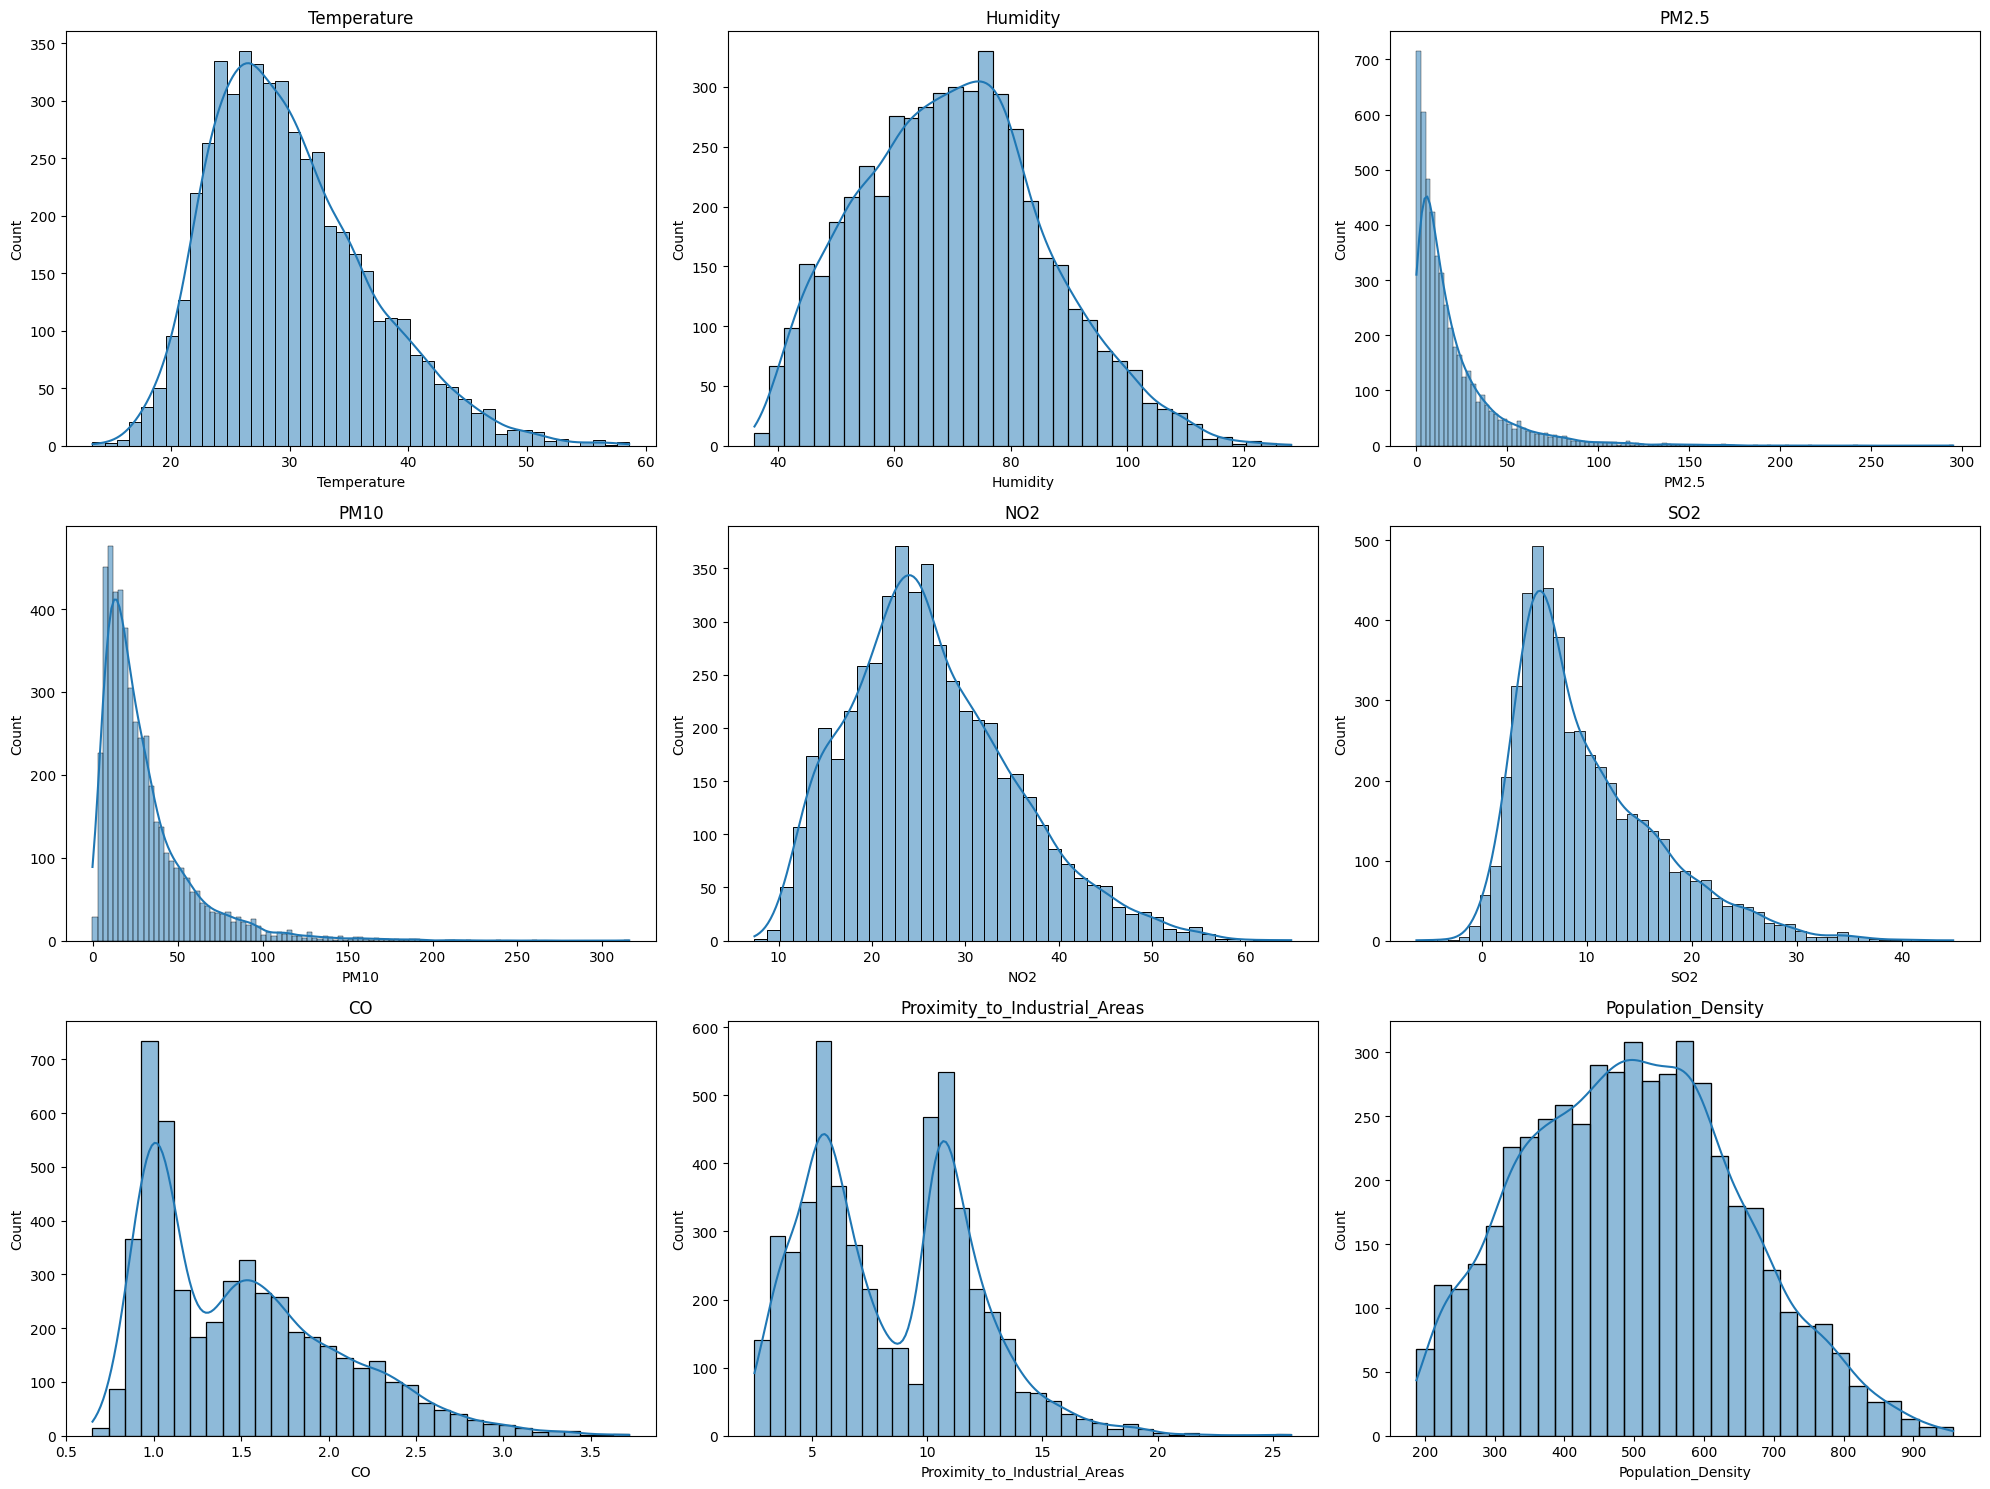

In [154]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=['float64','int64']).columns

plt.figure(figsize=(20,15))
for i,col in enumerate(num_cols,1):
    plt.subplot(3,3,i)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

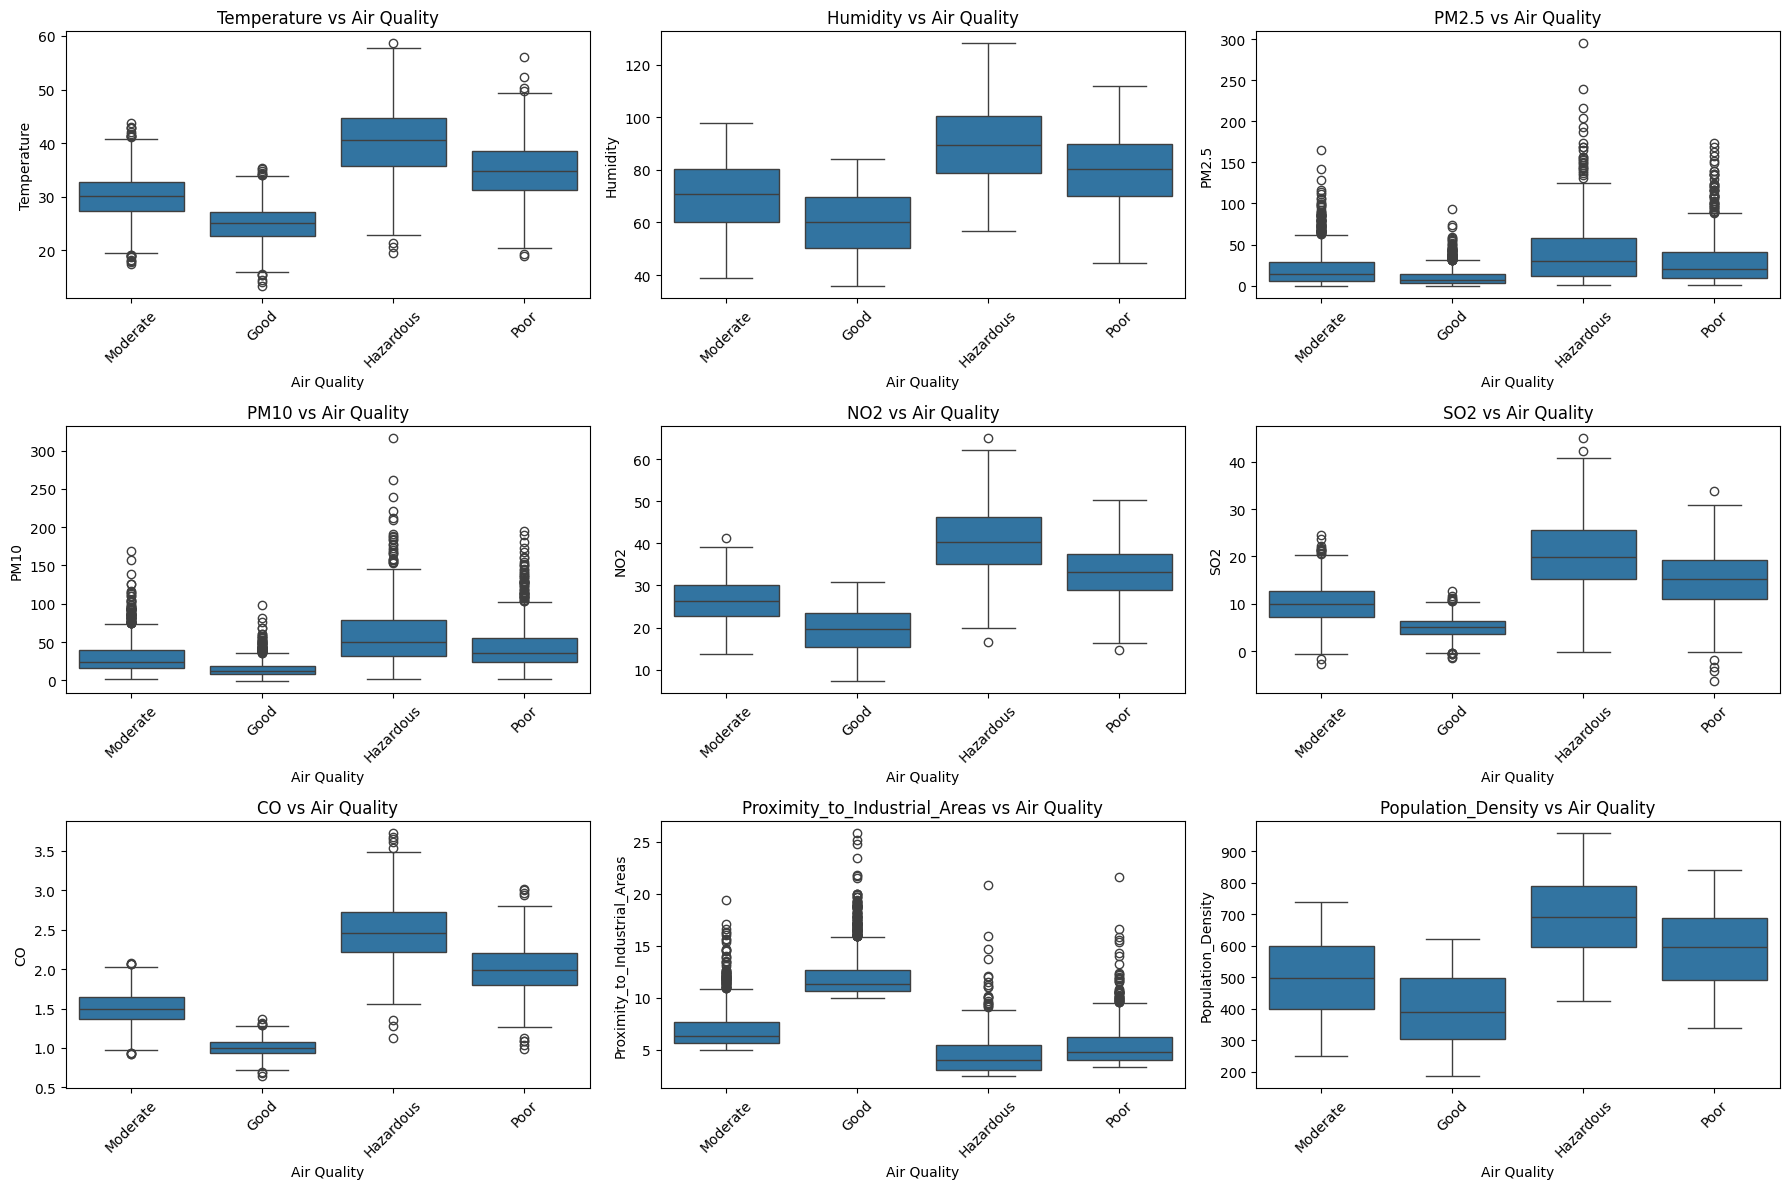

In [155]:
plt.figure(figsize=(18,12))
for i,col in enumerate(num_cols,1):
    plt.subplot(3,3,i)
    sns.boxplot(x="Air Quality", y=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Air Quality")
plt.tight_layout()
plt.show()

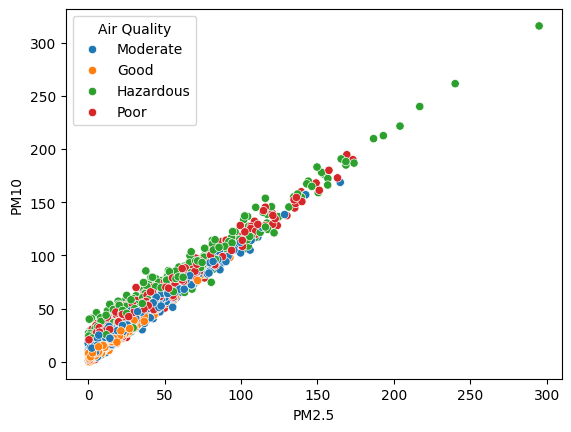

In [156]:
sns.scatterplot(x="PM2.5", y="PM10", hue="Air Quality", data=df)
plt.show()

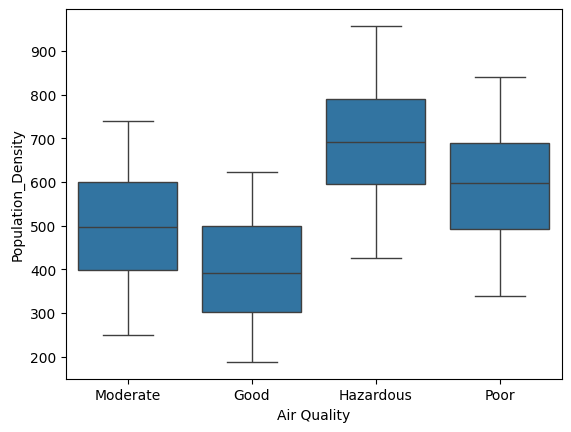

In [157]:
sns.boxplot(x="Air Quality", y="Population_Density", data=df)
plt.show()

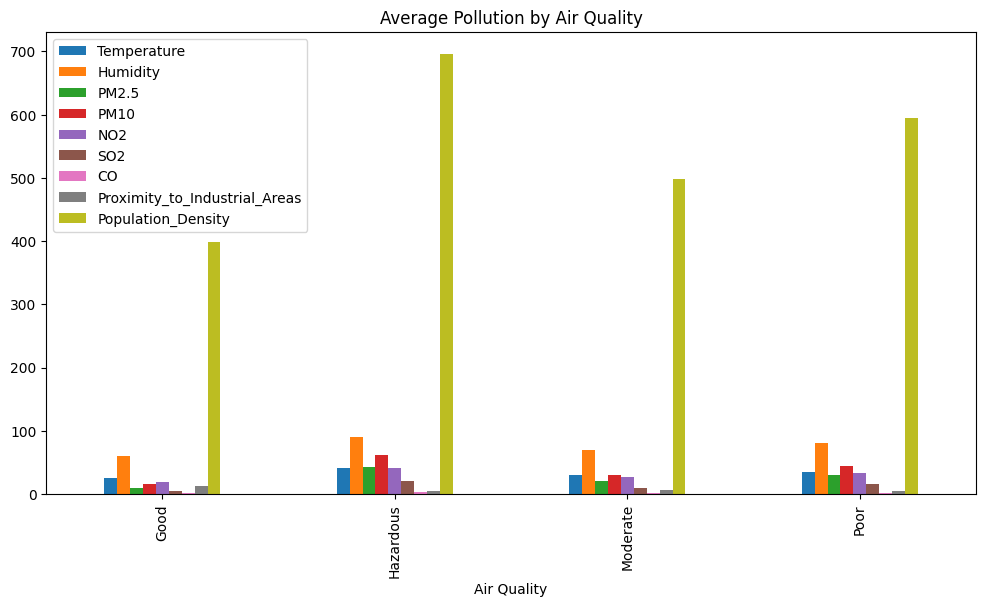

In [158]:
df.groupby("Air Quality").mean().plot(kind="bar", figsize=(12,6))
plt.title("Average Pollution by Air Quality")
plt.show()

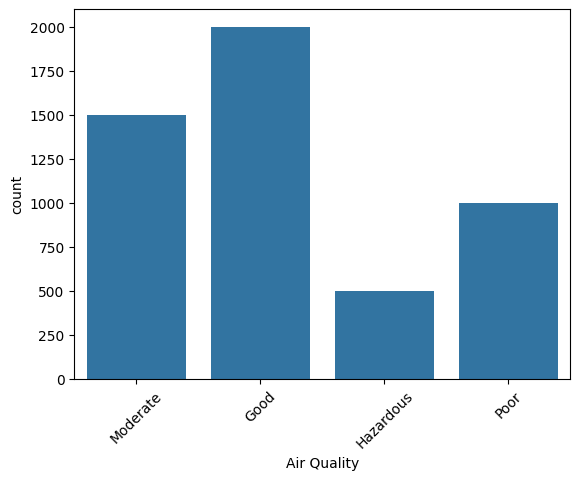

In [159]:
sns.countplot(x="Air Quality", data=df)
plt.xticks(rotation=45)
plt.show()

In [160]:
mapping = {
    "Good": 0,
    "Moderate": 1,
    "Poor": 2,
    "Hazardous": 3
}

df["Air Quality"] = df["Air Quality"].map(mapping)

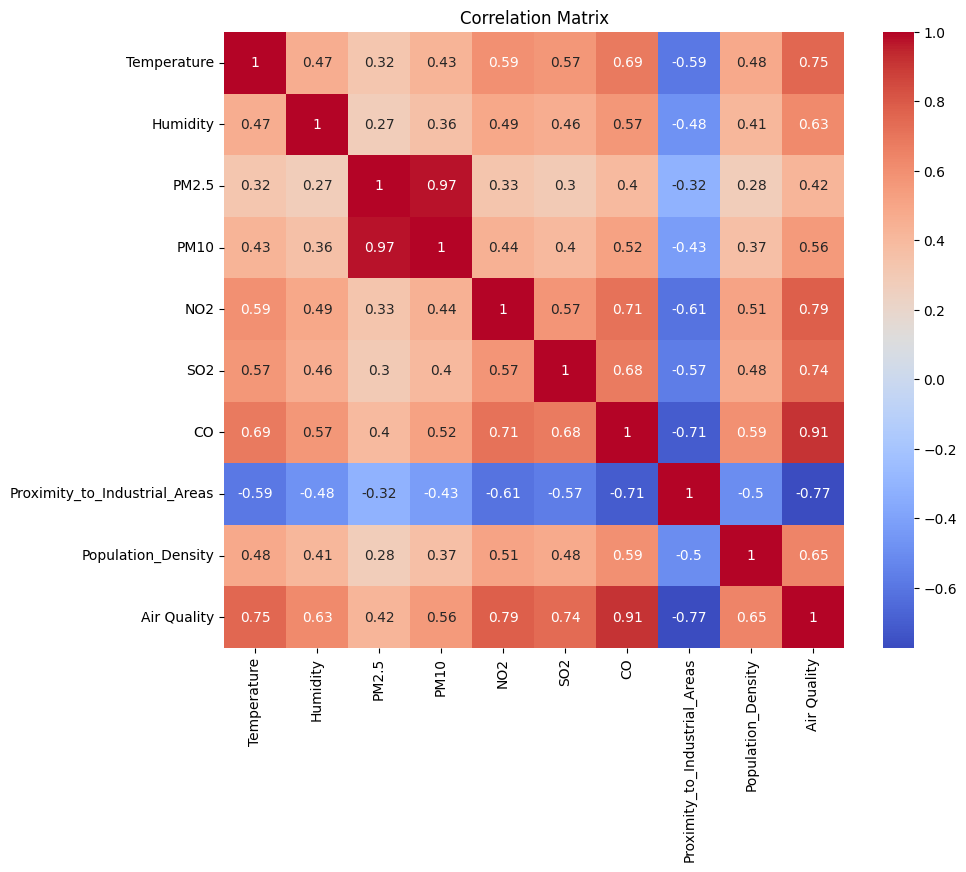

In [161]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [162]:
X=df.drop("Air Quality",axis=1)
y=df["Air Quality"]

In [163]:
df.columns

Index(['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO',
       'Proximity_to_Industrial_Areas', 'Population_Density', 'Air Quality'],
      dtype='object')

In [164]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [165]:
skewed_cols = ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO',
       'Proximity_to_Industrial_Areas', 'Population_Density']
pt = PowerTransformer(method='yeo-johnson')

X_train = pt.fit_transform(X_train)
X_test  = pt.transform(X_test)

In [167]:
models = {

    # Linear
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=1),

    # Distance-based
    "KNN": KNeighborsClassifier(n_neighbors=5),

    # SVM
    "SVC": SVC(probability=True, random_state=1),

    # Tree
    "Decision Tree": DecisionTreeClassifier(random_state=1),

    # Naive Bayes
    "Naive Bayes": GaussianNB(),

    # Bagging Based
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=1),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=1),

    # Boosting
    "AdaBoost": AdaBoostClassifier(random_state=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=1),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=1),

    # External Boosting Libraries
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=1, use_label_encoder=False),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=1),
    "LightGBM": LGBMClassifier(random_state=1)
}

  0%|          | 0/13 [00:00<?, ?it/s]


================ Logistic Regression ================

Confusion Matrix:
 [[398   2   0   0]
 [  2 285  13   0]
 [  1  12 179   8]
 [  0   0  19  81]]


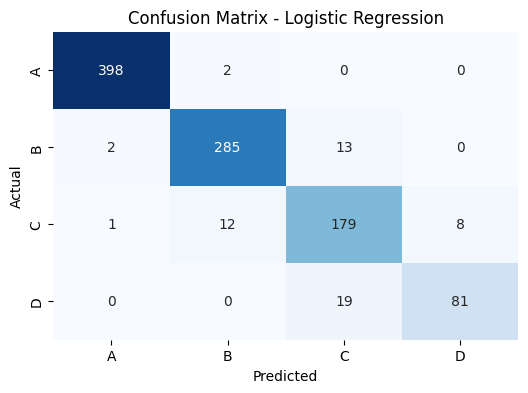


Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       400
           1       0.95      0.95      0.95       300
           2       0.85      0.90      0.87       200
           3       0.91      0.81      0.86       100

    accuracy                           0.94      1000
   macro avg       0.93      0.91      0.92      1000
weighted avg       0.94      0.94      0.94      1000

ROC-AUC: 0.9940465873015873


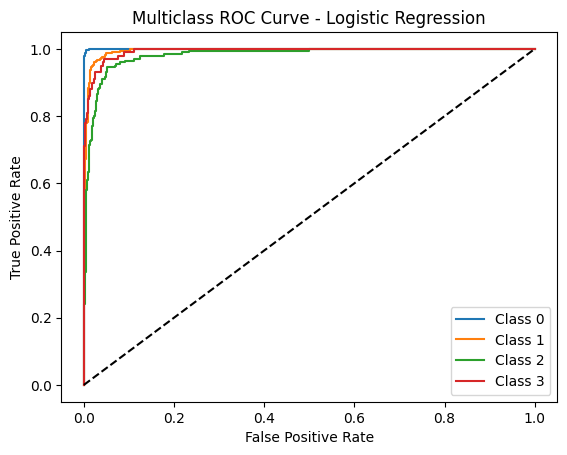

  8%|▊         | 1/13 [00:00<00:08,  1.39it/s]

PR AUC: 0.9770967505228075

================ KNN ================

Confusion Matrix:
 [[399   1   0   0]
 [  4 292   4   0]
 [  0  29 165   6]
 [  0   1  38  61]]


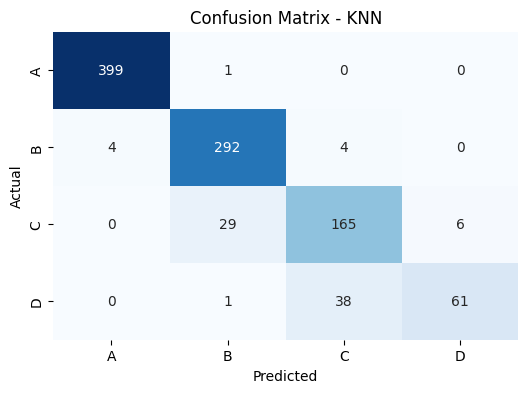


Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       400
           1       0.90      0.97      0.94       300
           2       0.80      0.82      0.81       200
           3       0.91      0.61      0.73       100

    accuracy                           0.92      1000
   macro avg       0.90      0.85      0.87      1000
weighted avg       0.92      0.92      0.91      1000

ROC-AUC: 0.9830089384920635


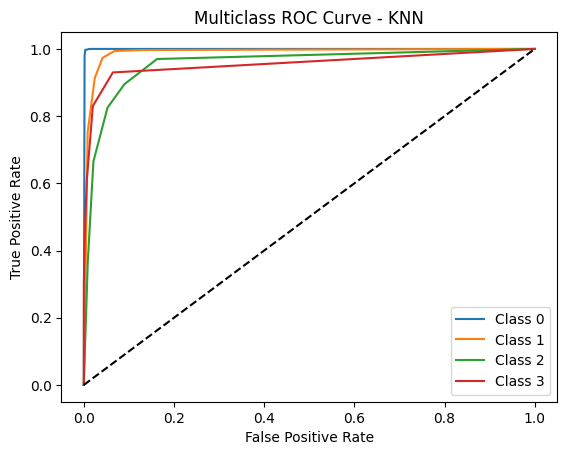

 15%|█▌        | 2/13 [00:01<00:10,  1.09it/s]

PR AUC: 0.9362868515725081

================ SVC ================

Confusion Matrix:
 [[399   1   0   0]
 [  1 290   9   0]
 [  0  10 183   7]
 [  0   0  14  86]]


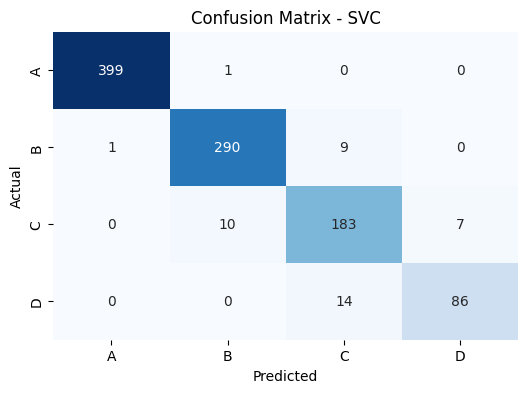


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.96      0.97      0.97       300
           2       0.89      0.92      0.90       200
           3       0.92      0.86      0.89       100

    accuracy                           0.96      1000
   macro avg       0.94      0.93      0.94      1000
weighted avg       0.96      0.96      0.96      1000

ROC-AUC: 0.9959064682539682


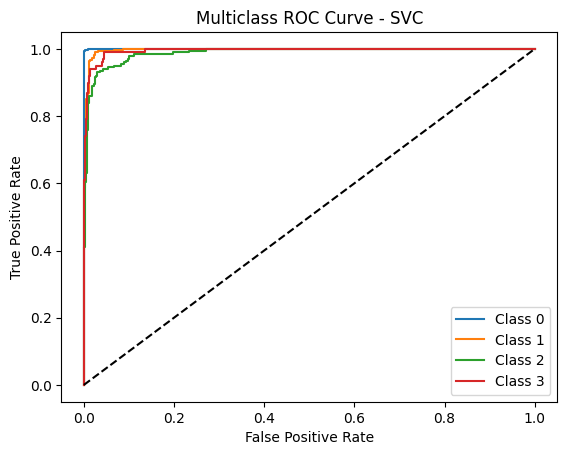

 23%|██▎       | 3/13 [00:05<00:20,  2.06s/it]

PR AUC: 0.9844717368734477

================ Decision Tree ================

Confusion Matrix:
 [[399   1   0   0]
 [  3 272  25   0]
 [  0  24 159  17]
 [  0   0  18  82]]


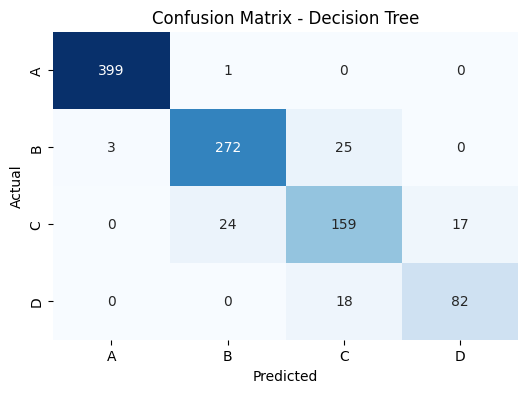


Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       400
           1       0.92      0.91      0.91       300
           2       0.79      0.80      0.79       200
           3       0.83      0.82      0.82       100

    accuracy                           0.91      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.91      0.91      0.91      1000

ROC-AUC: 0.9433234126984127


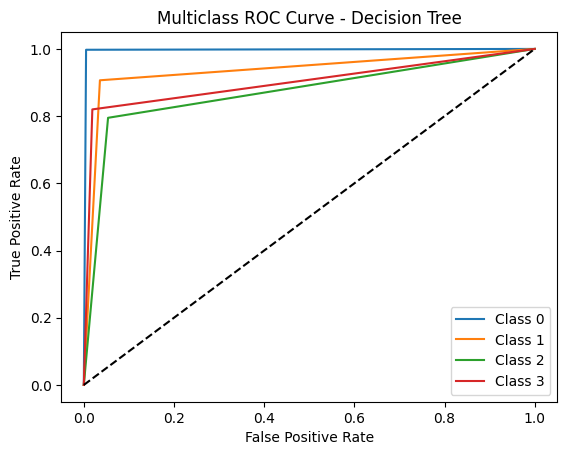

 31%|███       | 4/13 [00:05<00:13,  1.49s/it]

PR AUC: 0.8569994224298052

================ Naive Bayes ================

Confusion Matrix:
 [[399   1   0   0]
 [  1 288  11   0]
 [  0  11 182   7]
 [  0   0  18  82]]


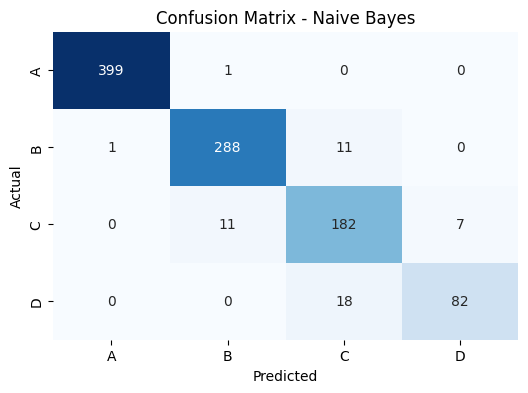


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.96      0.96      0.96       300
           2       0.86      0.91      0.89       200
           3       0.92      0.82      0.87       100

    accuracy                           0.95      1000
   macro avg       0.94      0.92      0.93      1000
weighted avg       0.95      0.95      0.95      1000

ROC-AUC: 0.9938508333333335


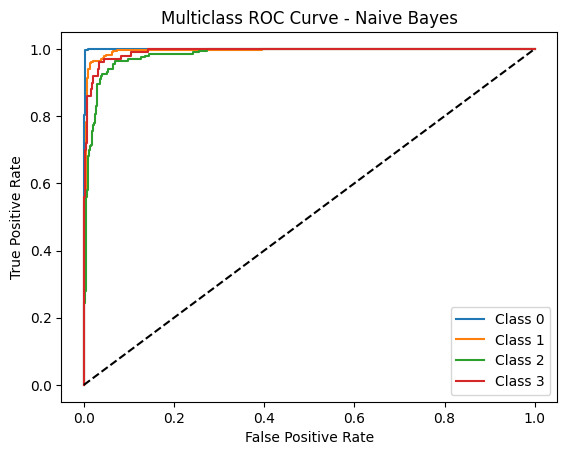

 38%|███▊      | 5/13 [00:06<00:09,  1.14s/it]

PR AUC: 0.9737862203534458

================ Random Forest ================

Confusion Matrix:
 [[400   0   0   0]
 [  1 284  15   0]
 [  0   6 187   7]
 [  0   0  16  84]]


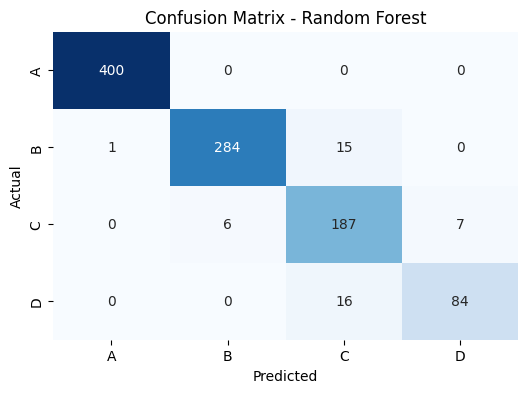


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.98      0.95      0.96       300
           2       0.86      0.94      0.89       200
           3       0.92      0.84      0.88       100

    accuracy                           0.95      1000
   macro avg       0.94      0.93      0.93      1000
weighted avg       0.96      0.95      0.96      1000

ROC-AUC: 0.9961246130952381


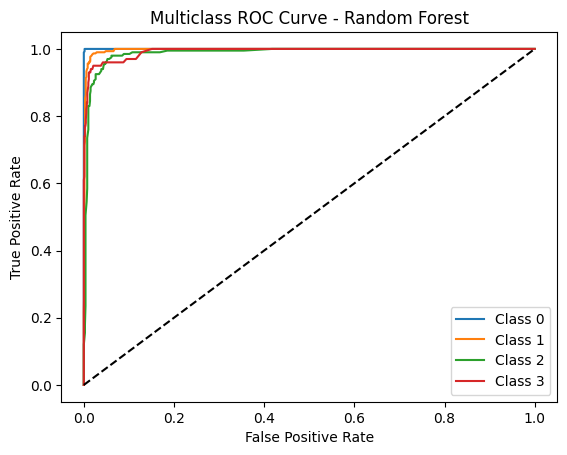

 46%|████▌     | 6/13 [00:07<00:08,  1.21s/it]

PR AUC: 0.9820205471063269

================ Extra Trees ================

Confusion Matrix:
 [[400   0   0   0]
 [  1 292   7   0]
 [  0   8 189   3]
 [  0   0  14  86]]


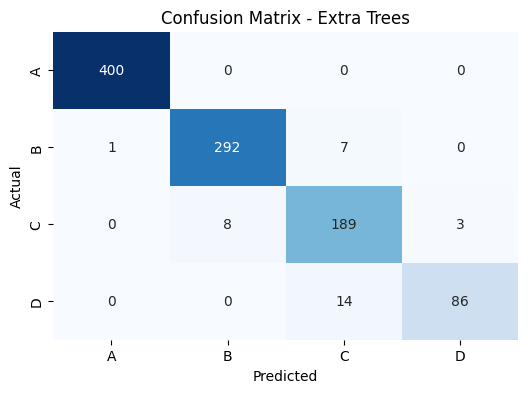


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.97      0.97      0.97       300
           2       0.90      0.94      0.92       200
           3       0.97      0.86      0.91       100

    accuracy                           0.97      1000
   macro avg       0.96      0.94      0.95      1000
weighted avg       0.97      0.97      0.97      1000

ROC-AUC: 0.996542380952381


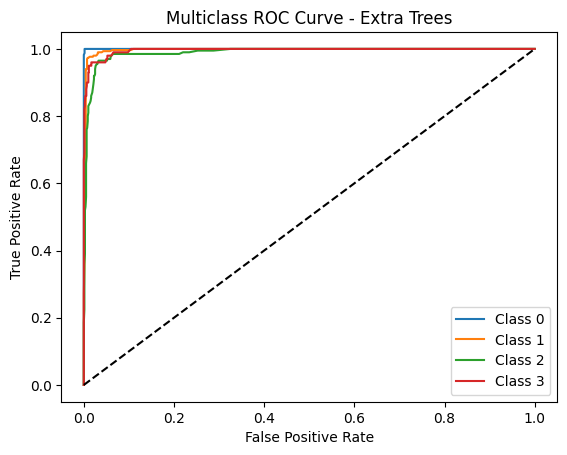

 54%|█████▍    | 7/13 [00:08<00:06,  1.07s/it]

PR AUC: 0.986047603298031

================ AdaBoost ================

Confusion Matrix:
 [[198 202   0   0]
 [  0 246  54   0]
 [  0   4 188   8]
 [  0   0  37  63]]


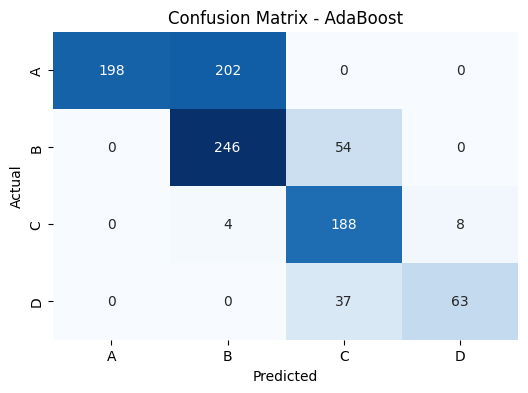


Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.49      0.66       400
           1       0.54      0.82      0.65       300
           2       0.67      0.94      0.78       200
           3       0.89      0.63      0.74       100

    accuracy                           0.69      1000
   macro avg       0.78      0.72      0.71      1000
weighted avg       0.79      0.69      0.69      1000

ROC-AUC: 0.8972562797619047


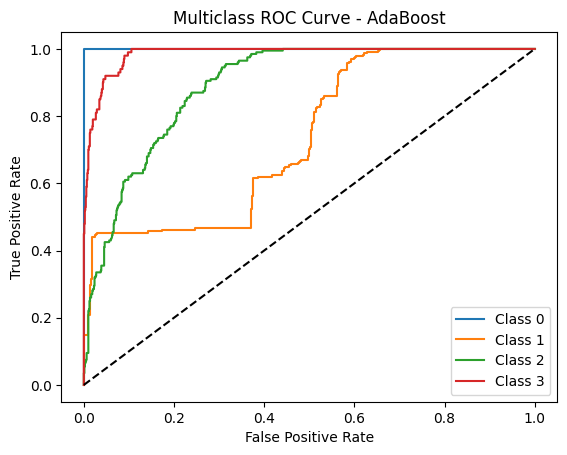

 62%|██████▏   | 8/13 [00:09<00:04,  1.07it/s]

PR AUC: 0.8096251467838596

================ Gradient Boosting ================

Confusion Matrix:
 [[400   0   0   0]
 [  3 286  11   0]
 [  0   7 185   8]
 [  0   0  18  82]]


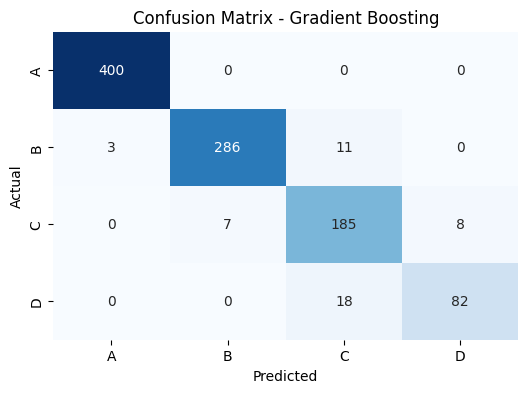


Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       400
           1       0.98      0.95      0.96       300
           2       0.86      0.93      0.89       200
           3       0.91      0.82      0.86       100

    accuracy                           0.95      1000
   macro avg       0.94      0.92      0.93      1000
weighted avg       0.95      0.95      0.95      1000

ROC-AUC: 0.9958617261904761


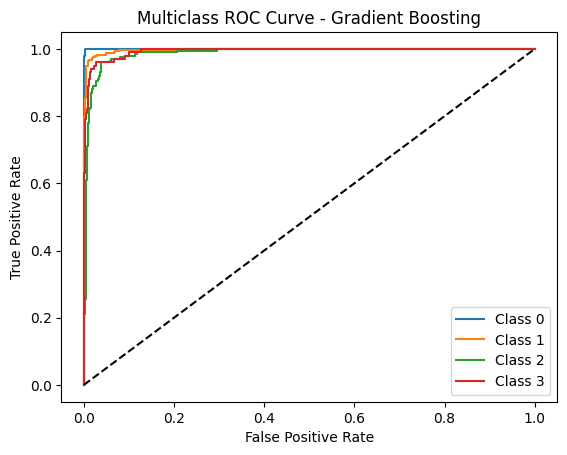

PR AUC:

 69%|██████▉   | 9/13 [00:13<00:08,  2.05s/it]

 0.9825263299154303

================ Hist Gradient Boosting ================

Confusion Matrix:
 [[400   0   0   0]
 [  1 289  10   0]
 [  0   8 188   4]
 [  0   0  15  85]]


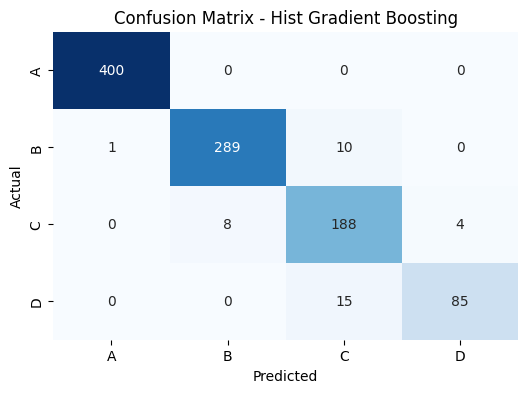


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.97      0.96      0.97       300
           2       0.88      0.94      0.91       200
           3       0.96      0.85      0.90       100

    accuracy                           0.96      1000
   macro avg       0.95      0.94      0.94      1000
weighted avg       0.96      0.96      0.96      1000

ROC-AUC: 0.9965810119047619


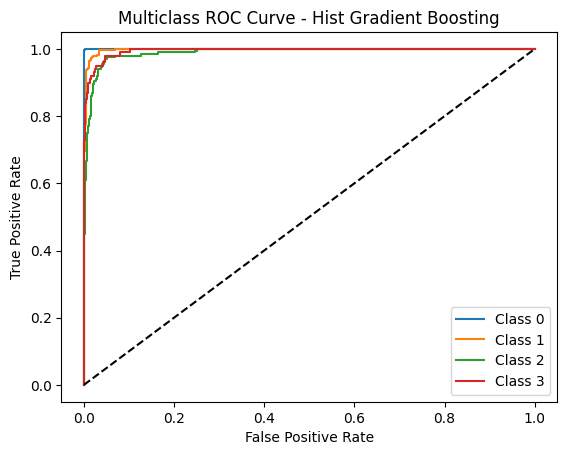

 77%|███████▋  | 10/13 [00:15<00:05,  1.99s/it]

PR AUC: 0.9864238959866644

================ XGBoost ================


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:40:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Confusion Matrix:
 [[400   0   0   0]
 [  2 283  15   0]
 [  0  10 183   7]
 [  0   0  15  85]]


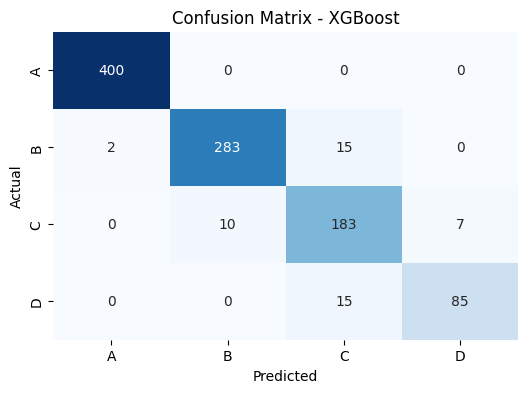


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.97      0.94      0.95       300
           2       0.86      0.92      0.89       200
           3       0.92      0.85      0.89       100

    accuracy                           0.95      1000
   macro avg       0.94      0.93      0.93      1000
weighted avg       0.95      0.95      0.95      1000

ROC-AUC: 0.9962259722222222


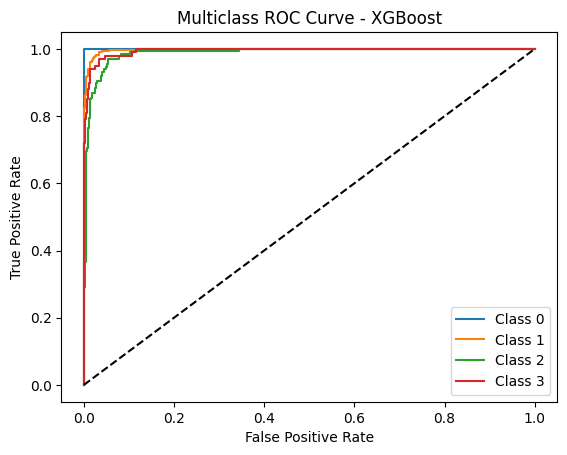

 85%|████████▍ | 11/13 [00:17<00:04,  2.09s/it]

PR AUC: 0.9843768215987682

================ CatBoost ================

Confusion Matrix:
 [[400   0   0   0]
 [  0 291   9   0]
 [  0   6 188   6]
 [  0   0  15  85]]


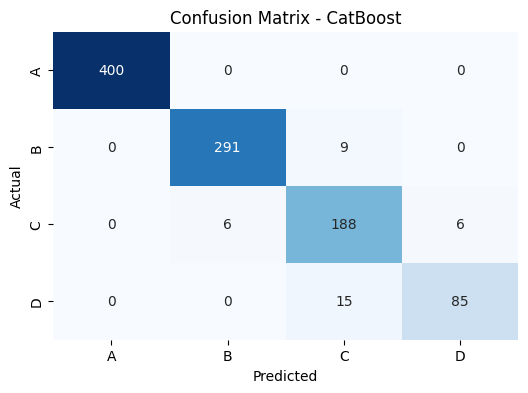


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.98      0.97      0.97       300
           2       0.89      0.94      0.91       200
           3       0.93      0.85      0.89       100

    accuracy                           0.96      1000
   macro avg       0.95      0.94      0.94      1000
weighted avg       0.96      0.96      0.96      1000

ROC-AUC: 0.9964263095238095


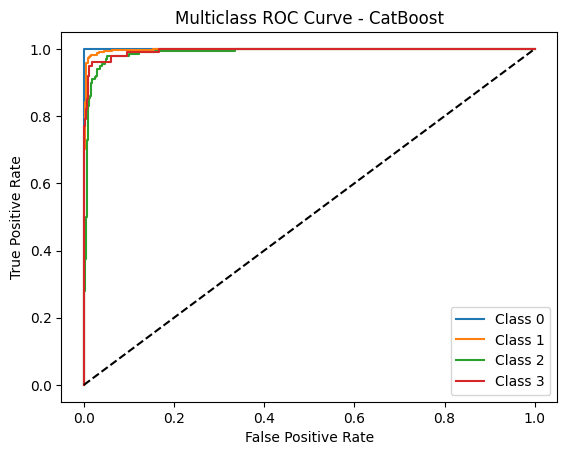

 92%|█████████▏| 12/13 [00:27<00:04,  4.50s/it]

PR AUC: 0.9845206163091516

================ LightGBM ================
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000810 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2193
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 9
[LightGBM] [Info] Start training from score -0.916291
[LightGBM] [Info] Start training from score -1.203973
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Confusion Matrix:
 [[400   0   0   0]
 [  1 288  11   0]
 [  0  10 183   7]
 [  0   0  15  85]]


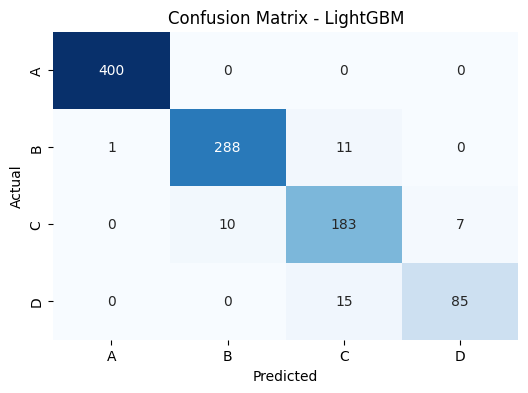


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.97      0.96      0.96       300
           2       0.88      0.92      0.89       200
           3       0.92      0.85      0.89       100

    accuracy                           0.96      1000
   macro avg       0.94      0.93      0.94      1000
weighted avg       0.96      0.96      0.96      1000

ROC-AUC: 0.9965981349206349


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


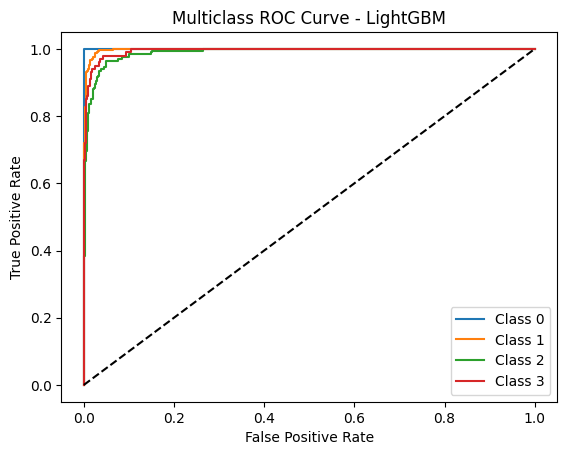

100%|██████████| 13/13 [00:29<00:00,  2.26s/it]

PR AUC: 0.9863680998851415


In [169]:
import numpy as np

results = {}

for name, model in tqdm(models.items()):
    print(f"\n================ {name} ================")

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred  = model.predict(X_test)

    results[name] = {
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train Precision": precision_score(y_train, train_pred, average='weighted'),
        "Test Precision": precision_score(y_test, test_pred, average='weighted'),
        "Train Recall": recall_score(y_train, train_pred, average='weighted'),
        "Test Recall": recall_score(y_test, test_pred, average='weighted'),
        "Train F1 Score": f1_score(y_train, train_pred, average='weighted'),
        "Test F1 Score": f1_score(y_test, test_pred, average='weighted'),
        "Train Balanced Accuracy": balanced_accuracy_score(y_train, train_pred),
        "Test Balanced Accuracy": balanced_accuracy_score(y_test, test_pred)
    }

    # ================= Confusion Matrix =================
    cm = confusion_matrix(y_test, test_pred)
    print("\nConfusion Matrix:\n", cm)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', cbar=False,
                xticklabels=['A','B',"C",'D'],
                yticklabels=['A','B',"C",'D'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

    # ================= Classification Report =================
    print("\nClassification Report:\n")
    print(classification_report(y_test, test_pred, zero_division=0))

    # ================= ROC-AUC (Multiclass) =================
    if hasattr(model, "predict_proba"):
        y_pred_prob = model.predict_proba(X_test)

        roc_auc = roc_auc_score(
            y_test,
            y_pred_prob,
            multi_class='ovr',
            average='weighted'
        )

        print("ROC-AUC:", roc_auc)

        # Multiclass ROC Curve
        classes = np.unique(y_test)
        y_test_bin = label_binarize(y_test, classes=classes)

        plt.figure()

        for i in range(len(classes)):
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
            plt.plot(fpr, tpr, label=f'Class {classes[i]}')

        plt.plot([0,1],[0,1],'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'Multiclass ROC Curve - {name}')
        plt.legend()
        plt.show()

        # ================= PR Curve =================
        pr_auc = average_precision_score(
            y_test_bin,
            y_pred_prob,
            average='weighted'
        )
        print("PR AUC:", pr_auc)

    else:
        print("Model does not support predict_proba()")


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Confusion Matrix:
 [[399   1   0   0]
 [  1 287  12   0]
 [  0   7 186   7]
 [  0   0  15  85]]


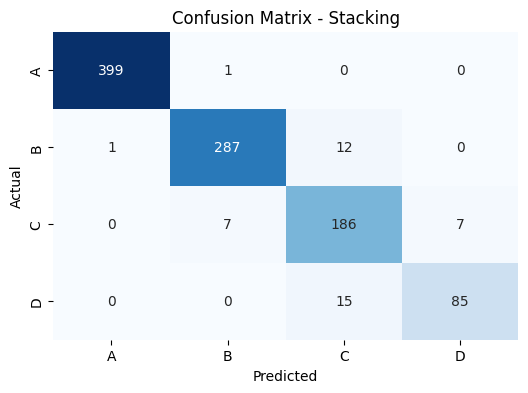


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.97      0.96      0.96       300
           2       0.87      0.93      0.90       200
           3       0.92      0.85      0.89       100

    accuracy                           0.96      1000
   macro avg       0.94      0.93      0.94      1000
weighted avg       0.96      0.96      0.96      1000

ROC-AUC: 0.9964587698412698


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


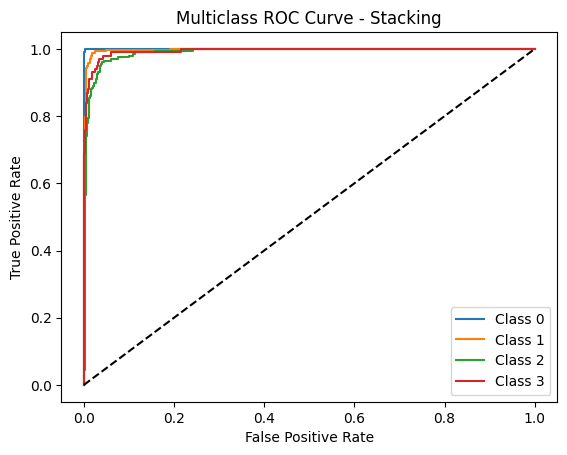

PR AUC: 0.981675928239743


In [170]:
from sklearn.preprocessing import label_binarize
import numpy as np

stack_auto = StackingClassifier(
    estimators=[
        ("lr", models["Logistic Regression"]),
        ("rf", models["Random Forest"]),
        ("nb", models["Naive Bayes"]),
        ("lgbm", models["LightGBM"]),
    ],
    final_estimator=XGBClassifier(),
    stack_method="predict_proba",
    n_jobs=-1
)

# Train
stack_auto.fit(X_train, y_train)

# Predictions
stack_auto_train_pred = stack_auto.predict(X_train)
stack_auto_test_pred  = stack_auto.predict(X_test)

results["Stacking Classifier"] = {
    "Train Accuracy": accuracy_score(y_train, stack_auto_train_pred),
    "Test Accuracy": accuracy_score(y_test, stack_auto_test_pred),
    "Train Precision": precision_score(y_train, stack_auto_train_pred, average='weighted'),
    "Test Precision": precision_score(y_test, stack_auto_test_pred, average='weighted'),
    "Train Recall": recall_score(y_train, stack_auto_train_pred, average='weighted'),
    "Test Recall": recall_score(y_test, stack_auto_test_pred, average='weighted'),
    "Train F1 Score": f1_score(y_train, stack_auto_train_pred, average='weighted'),
    "Test F1 Score": f1_score(y_test, stack_auto_test_pred, average='weighted'),
    "Train Balanced Accuracy": balanced_accuracy_score(y_train, stack_auto_train_pred),
    "Test Balanced Accuracy": balanced_accuracy_score(y_test, stack_auto_test_pred)
}

# ================= Confusion Matrix =================
cm = confusion_matrix(y_test, stack_auto_test_pred)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', cbar=False,
            xticklabels=['A','B',"C",'D'],
            yticklabels=['A','B',"C",'D'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Stacking')
plt.show()

# ================= Classification Report =================
print("\nClassification Report:\n")
print(classification_report(y_test, stack_auto_test_pred, zero_division=0))

# ================= ROC-AUC (Multiclass) =================
if hasattr(stack_auto, "predict_proba"):

    y_pred_prob = stack_auto.predict_proba(X_test)

    roc_auc = roc_auc_score(
        y_test,
        y_pred_prob,
        multi_class='ovr',
        average='weighted'
    )

    print("ROC-AUC:", roc_auc)

    # Multiclass ROC Curves
    classes = np.unique(y_test)
    y_test_bin = label_binarize(y_test, classes=classes)

    plt.figure()

    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
        plt.plot(fpr, tpr, label=f'Class {classes[i]}')

    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC Curve - Stacking')
    plt.legend()
    plt.show()

    # ================= PR AUC =================
    pr_auc = average_precision_score(
        y_test_bin,
        y_pred_prob,
        average='weighted'
    )
    print("PR AUC:", pr_auc)

else:
    print("Stacking model does not support predict_proba()")


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:43:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Confusion Matrix:
 [[399   1   0   0]
 [  1 290   9   0]
 [  0   7 186   7]
 [  0   0  15  85]]


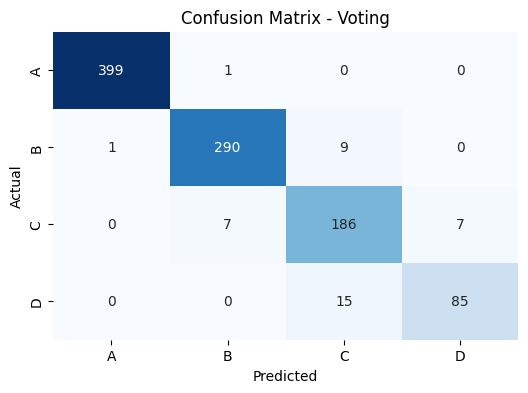


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.97      0.97      0.97       300
           2       0.89      0.93      0.91       200
           3       0.92      0.85      0.89       100

    accuracy                           0.96      1000
   macro avg       0.95      0.94      0.94      1000
weighted avg       0.96      0.96      0.96      1000

ROC-AUC: 0.9964866269841269


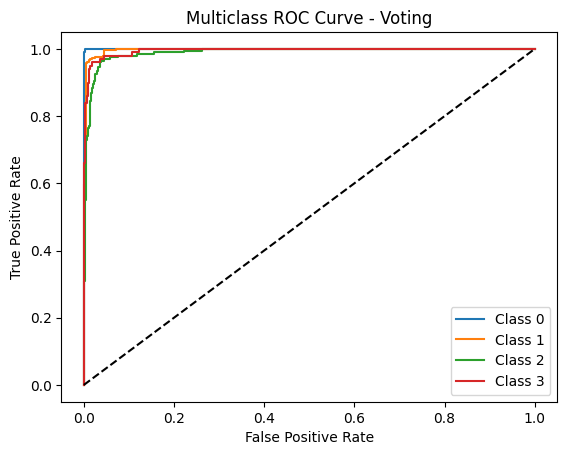

PR AUC: 0.9852118158216974


In [171]:
from sklearn.preprocessing import label_binarize
import numpy as np

voting_model = VotingClassifier(
    estimators=[
        ("lr", models["Logistic Regression"]),
        ("rf", models["Random Forest"]),
        ("nb", models["Naive Bayes"]),
        ("xgb", models["XGBoost"]),
    ],
    voting="soft"
)

voting_model.fit(X_train, y_train)

voting_train_pred = voting_model.predict(X_train)
voting_test_pred  = voting_model.predict(X_test)

results["Voting Classifier"] = {
    "Train Accuracy": accuracy_score(y_train, voting_train_pred),
    "Test Accuracy": accuracy_score(y_test, voting_test_pred),
    "Train Precision": precision_score(y_train, voting_train_pred, average='weighted'),
    "Test Precision": precision_score(y_test, voting_test_pred, average='weighted'),
    "Train Recall": recall_score(y_train, voting_train_pred, average='weighted'),
    "Test Recall": recall_score(y_test, voting_test_pred, average='weighted'),
    "Train F1 Score": f1_score(y_train, voting_train_pred, average='weighted'),
    "Test F1 Score": f1_score(y_test, voting_test_pred, average='weighted'),
    "Train Balanced Accuracy": balanced_accuracy_score(y_train, voting_train_pred),
    "Test Balanced Accuracy": balanced_accuracy_score(y_test, voting_test_pred)
}

# ================= Confusion Matrix =================
cm = confusion_matrix(y_test, voting_test_pred)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', cbar=False,
            xticklabels=['A','B',"C",'D'],
            yticklabels=['A','B',"C",'D'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Voting')
plt.show()

# ================= Classification Report =================
print("\nClassification Report:\n")
print(classification_report(y_test, voting_test_pred, zero_division=0))

# ================= ROC-AUC (Multiclass) =================
if hasattr(voting_model, "predict_proba"):

    y_pred_prob = voting_model.predict_proba(X_test)

    roc_auc = roc_auc_score(
        y_test,
        y_pred_prob,
        multi_class='ovr',
        average='weighted'
    )

    print("ROC-AUC:", roc_auc)

    # Multiclass ROC Curve
    classes = np.unique(y_test)
    y_test_bin = label_binarize(y_test, classes=classes)

    plt.figure()

    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
        plt.plot(fpr, tpr, label=f'Class {classes[i]}')

    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC Curve - Voting')
    plt.legend()
    plt.show()

    # ================= PR AUC =================
    pr_auc = average_precision_score(
        y_test_bin,
        y_pred_prob,
        average='weighted'
    )
    print("PR AUC:", pr_auc)

else:
    print("Voting model does not support predict_proba()")


In [173]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="Test F1 Score", ascending=False)

In [174]:
results_df

,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1 Score,Test F1 Score,Train Balanced Accuracy,Test Balanced Accuracy
Extra Trees,1.00000,0.967,1.000000,0.967632,1.00000,0.967,1.000000,0.966896,1.000000,0.944583
CatBoost,0.99950,0.964,0.999501,0.964704,0.99950,0.964,0.999500,0.963992,0.999375,0.940000
Hist Gradient Boosting,1.00000,0.962,1.000000,0.962953,1.00000,0.962,1.000000,0.961982,1.000000,0.938333
Voting Classifier,0.98825,0.960,0.988261,0.960480,0.98825,0.960,0.988214,0.959975,0.981458,0.936042
SVC,0.95475,0.958,0.954214,0.958180,0.95475,0.958,0.954296,0.957932,0.926094,0.934792
Stacking Classifier,0.99750,0.957,0.997504,0.957904,0.99750,0.957,0.997499,0.957099,0.997396,0.933542
LightGBM,1.00000,0.956,1.000000,0.956446,1.00000,0.956,1.000000,0.955979,1.000000,0.931250
Random Forest,1.00000,0.955,1.000000,0.956663,1.00000,0.955,1.000000,0.955220,1.000000,0.930417
Gradient Boosting,0.99000,0.953,0.990052,0.953863,0.99000,0.953,0.989972,0.952941,0.982500,0.924583
XGBoost,1.00000,0.951,1.000000,0.951993,1.00000,0.951,1.000000,0.951125,1.000000,0.927083
